In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/processed/credit_card_fraud_clean.csv')
print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['is_fraud'].mean()*100:.2f}%")

Shape: (20000, 26)
Fraud rate: 1.70%


C:\Users\uday dherange\AppData\Local\Temp\ipykernel_16072\218248448.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Fraud', 'Fraud'])


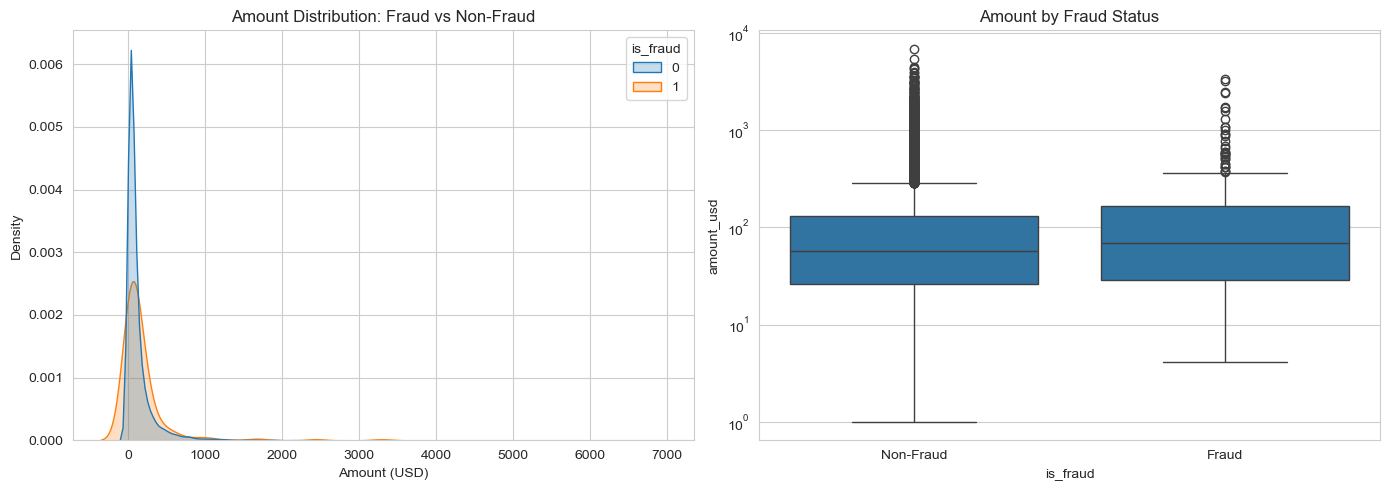

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution overlay
sns.kdeplot(data=df, x='amount_usd', hue='is_fraud', fill=True, common_norm=False, ax=axes[0])
axes[0].set_title('Amount Distribution: Fraud vs Non-Fraud')
axes[0].set_xlabel('Amount (USD)')

# Box plot
sns.boxplot(data=df, x='is_fraud', y='amount_usd', ax=axes[1])
axes[1].set_title('Amount by Fraud Status')
axes[1].set_xticklabels(['Non-Fraud', 'Fraud'])
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

C:\Users\uday dherange\AppData\Local\Temp\ipykernel_16072\460796751.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Non-Fraud', 'Fraud'])
C:\Users\uday dherange\AppData\Local\Temp\ipykernel_16072\460796751.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Non-Fraud', 'Fraud'])
C:\Users\uday dherange\AppData\Local\Temp\ipykernel_16072\460796751.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Non-Fraud', 'Fraud'])
C:\Users\uday dherange\AppData\Local\Temp\ipykernel_16072\460796751.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Non-Fraud', 'F

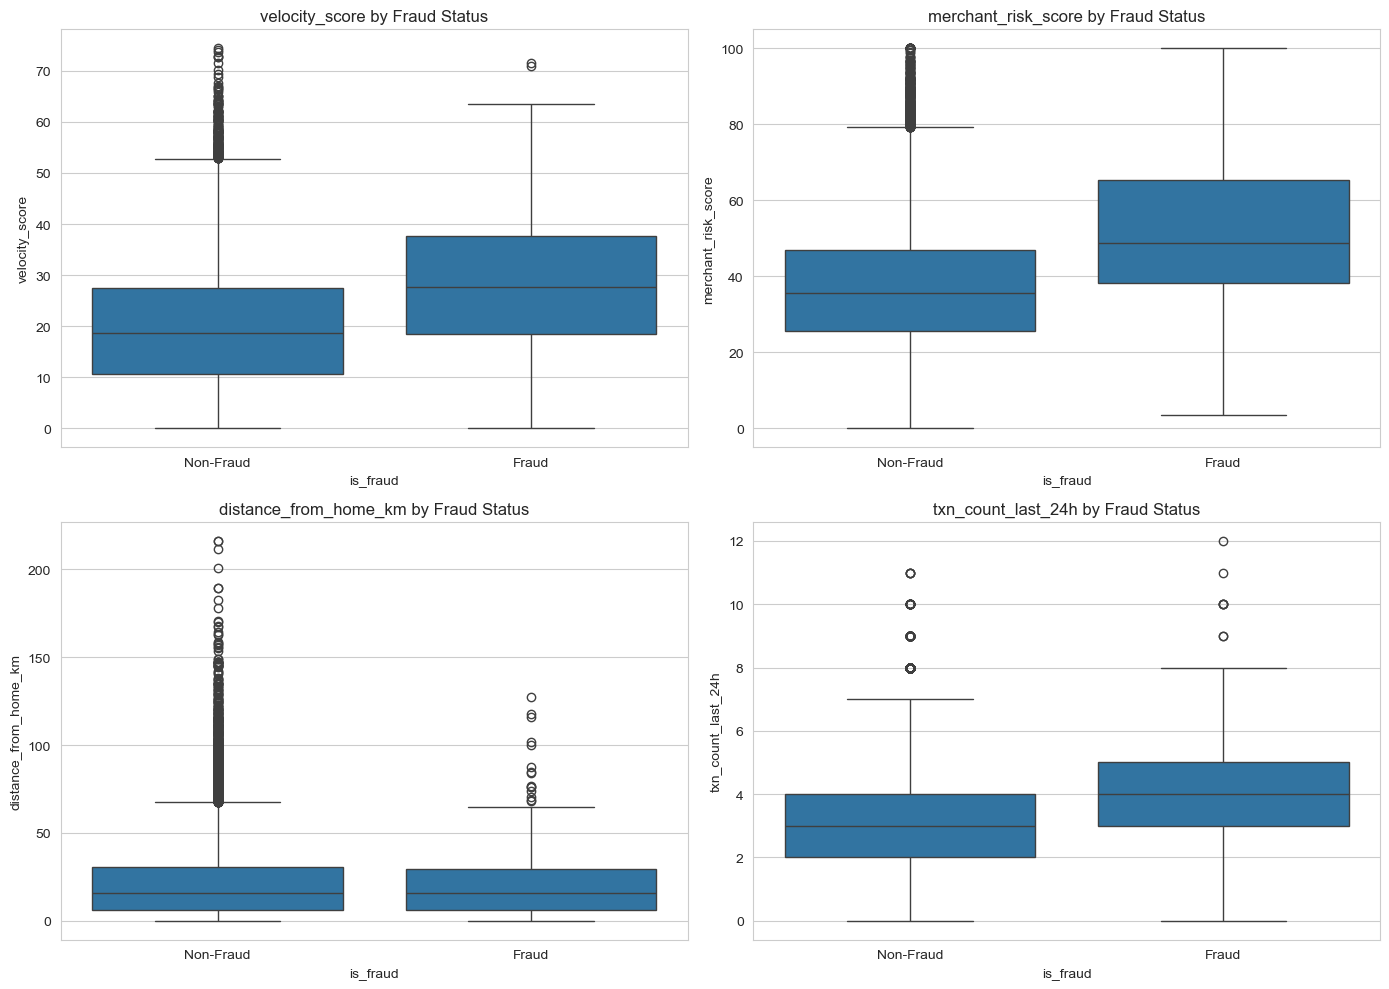

In [3]:
bivariate_cols = ['velocity_score', 'merchant_risk_score', 'distance_from_home_km', 'txn_count_last_24h']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(bivariate_cols):
    sns.boxplot(data=df, x='is_fraud', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Fraud Status')
    axes[i].set_xticklabels(['Non-Fraud', 'Fraud'])

plt.tight_layout()
plt.show()

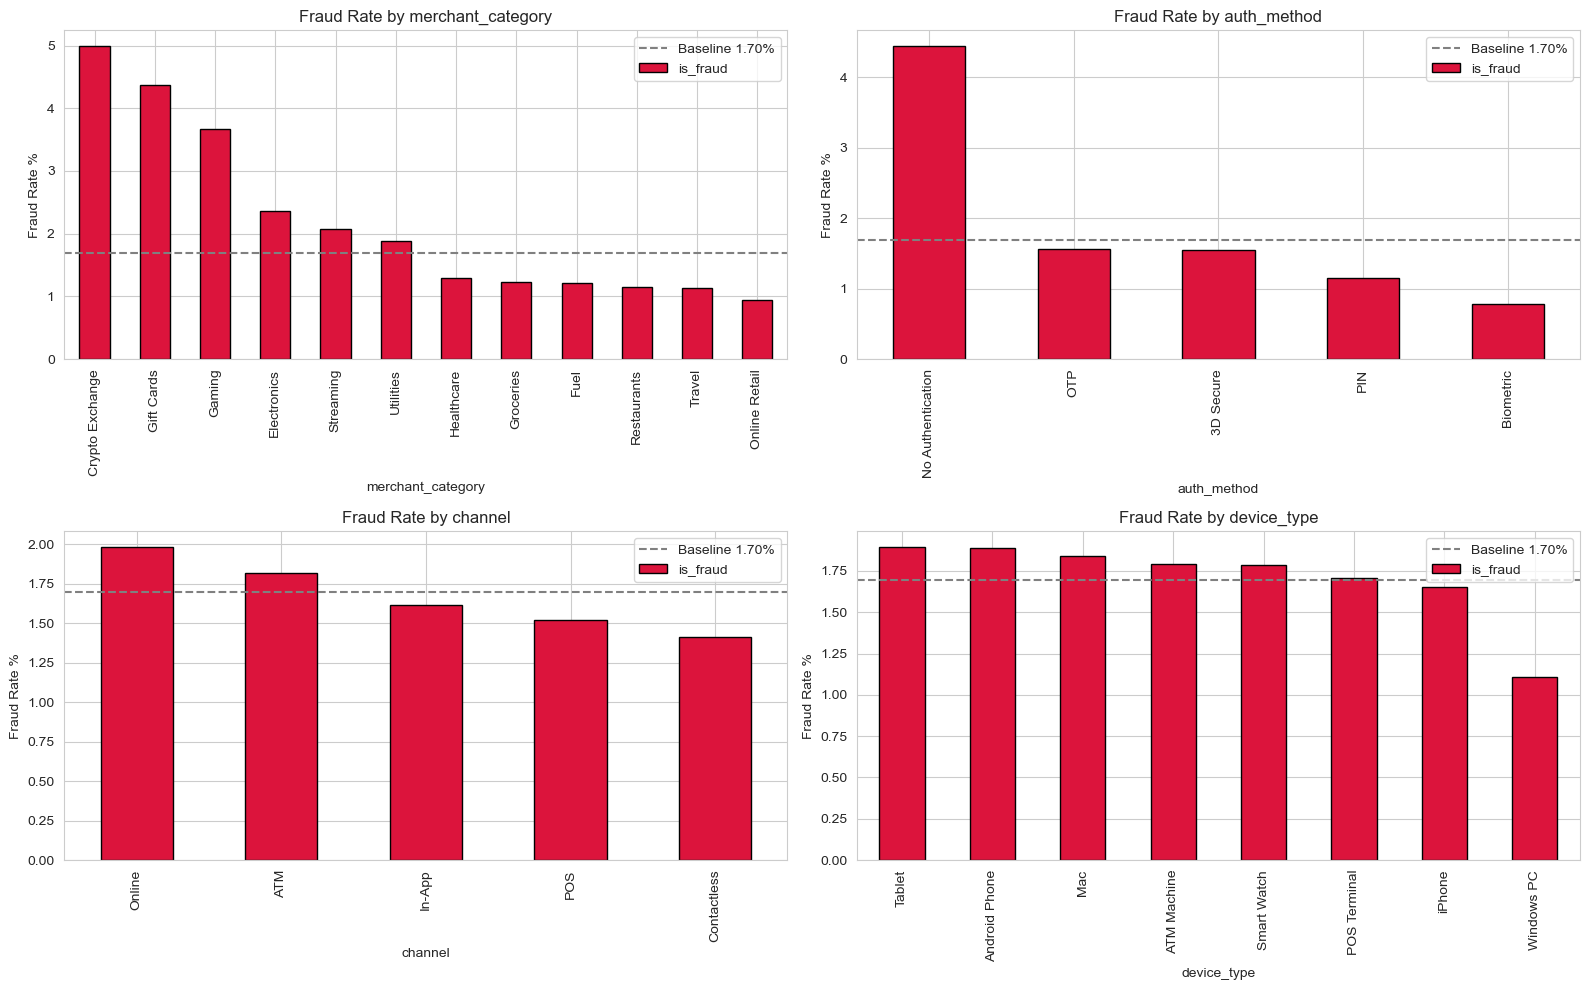

In [4]:
cat_cols = ['merchant_category', 'auth_method', 'channel', 'device_type']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

baseline = df['is_fraud'].mean() * 100

for i, col in enumerate(cat_cols):
    fraud_rate = df.groupby(col)['is_fraud'].mean() * 100
    fraud_rate = fraud_rate.sort_values(ascending=False)
    fraud_rate.plot(kind='bar', ax=axes[i], color='crimson', edgecolor='black')
    axes[i].axhline(baseline, ls='--', color='gray', label=f'Baseline {baseline:.2f}%')
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_ylabel('Fraud Rate %')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [5]:
binary_cols = [
    'is_foreign_transaction', 'is_new_merchant', 'used_vpn',
    'ip_country_mismatch', 'billing_shipping_mismatch',
    'is_ai_generated_scam_attempt'
]

fraud_rates = []
for col in binary_cols:
    rate_0 = df[df[col] == 0]['is_fraud'].mean() * 100
    rate_1 = df[df[col] == 1]['is_fraud'].mean() * 100
    fraud_rates.append({'flag': col, 'when_0': rate_0, 'when_1': rate_1, 'ratio': rate_1 / rate_0 if rate_0 > 0 else np.nan})

rates_df = pd.DataFrame(fraud_rates).round(2)
rates_df

,flag,when_0,when_1,ratio
0,is_foreign_transaction,1.42,5.89,4.15
1,is_new_merchant,1.16,3.50,3.03
2,used_vpn,1.44,4.38,3.05
3,ip_country_mismatch,1.32,7.80,5.93
4,billing_shipping_mismatch,1.42,7.79,5.50
5,is_ai_generated_scam_attempt,1.55,9.07,5.83


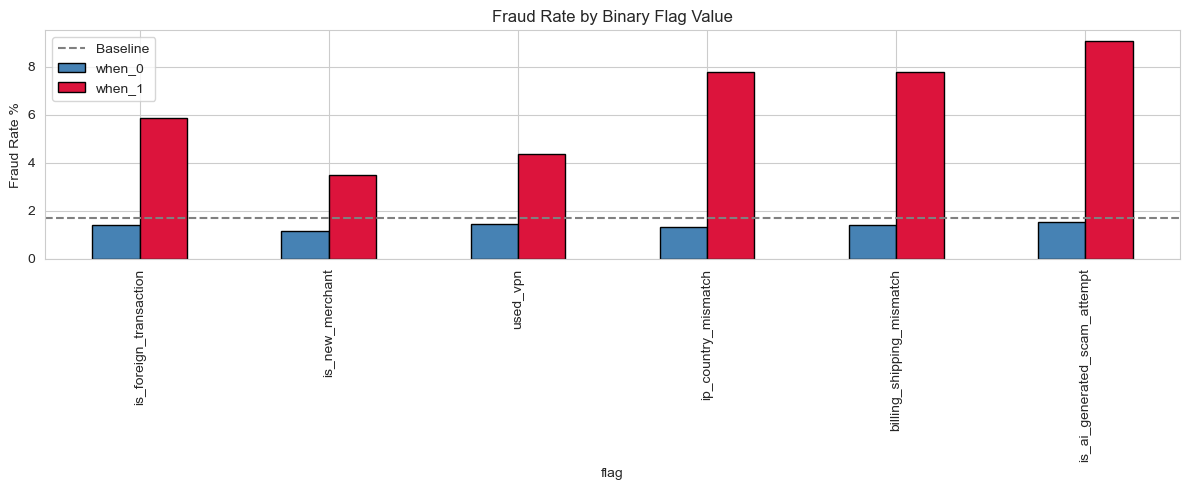

In [6]:
rates_df.set_index('flag')[['when_0', 'when_1']].plot(
    kind='bar', figsize=(12, 5), color=['steelblue', 'crimson'], edgecolor='black'
)
plt.axhline(df['is_fraud'].mean() * 100, ls='--', color='gray', label='Baseline')
plt.title('Fraud Rate by Binary Flag Value')
plt.ylabel('Fraud Rate %')
plt.legend()
plt.tight_layout()
plt.show()

Sample day mapping:
    day_of_week   day_name
2             0     Monday
5             1    Tuesday
32            2  Wednesday
0             3   Thursday
1             4     Friday
7             5   Saturday
3             6     Sunday

Day fraud rate:
day_name
Monday       1.614602
Tuesday      1.720578
Wednesday    1.539000
Thursday     1.886121
Friday       1.388889
Saturday     1.621622
Sunday       2.088326
Name: is_fraud, dtype: float64


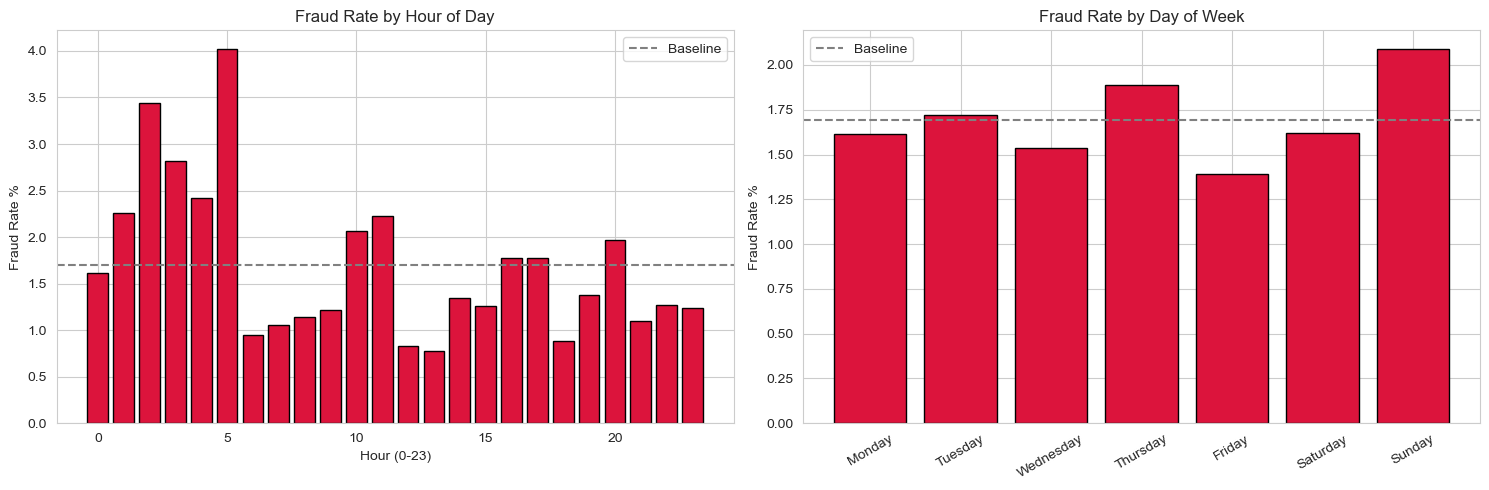


Temporary day_name column dropped.


In [10]:
day_map = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
           4: 'Friday', 5: 'Saturday', 6: 'Sunday'}

unique_days = sorted(df['day_of_week'].dropna().unique())
if 7 in unique_days and 0 not in unique_days:
    day_map = {1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday',
               5: 'Friday', 6: 'Saturday', 7: 'Sunday'}

df['day_name'] = df['day_of_week'].map(day_map)

print("Sample day mapping:")
print(df[['day_of_week', 'day_name']].drop_duplicates().sort_values('day_of_week'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Hour
hour_fraud = df.groupby('time_of_day_hour')['is_fraud'].mean() * 100
axes[0].bar(hour_fraud.index, hour_fraud.values, color='crimson', edgecolor='black')
axes[0].axhline(df['is_fraud'].mean() * 100, ls='--', color='gray', label='Baseline')
axes[0].set_title('Fraud Rate by Hour of Day')
axes[0].set_xlabel('Hour (0-23)')
axes[0].set_ylabel('Fraud Rate %')
axes[0].legend()

# Day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_fraud = df.groupby('day_name')['is_fraud'].mean() * 100
day_fraud = day_fraud.reindex([d for d in day_order if d in day_fraud.index])

print("\nDay fraud rate:")
print(day_fraud)

axes[1].bar(range(len(day_fraud)), day_fraud.values, color='crimson', edgecolor='black')
axes[1].set_xticks(range(len(day_fraud)))
axes[1].set_xticklabels(day_fraud.index, rotation=30)
axes[1].axhline(df['is_fraud'].mean() * 100, ls='--', color='gray', label='Baseline')
axes[1].set_title('Fraud Rate by Day of Week')
axes[1].set_ylabel('Fraud Rate %')
axes[1].legend()

plt.tight_layout()
plt.show()

df = df.drop(columns=['day_name'])
print("\nTemporary day_name column dropped.")

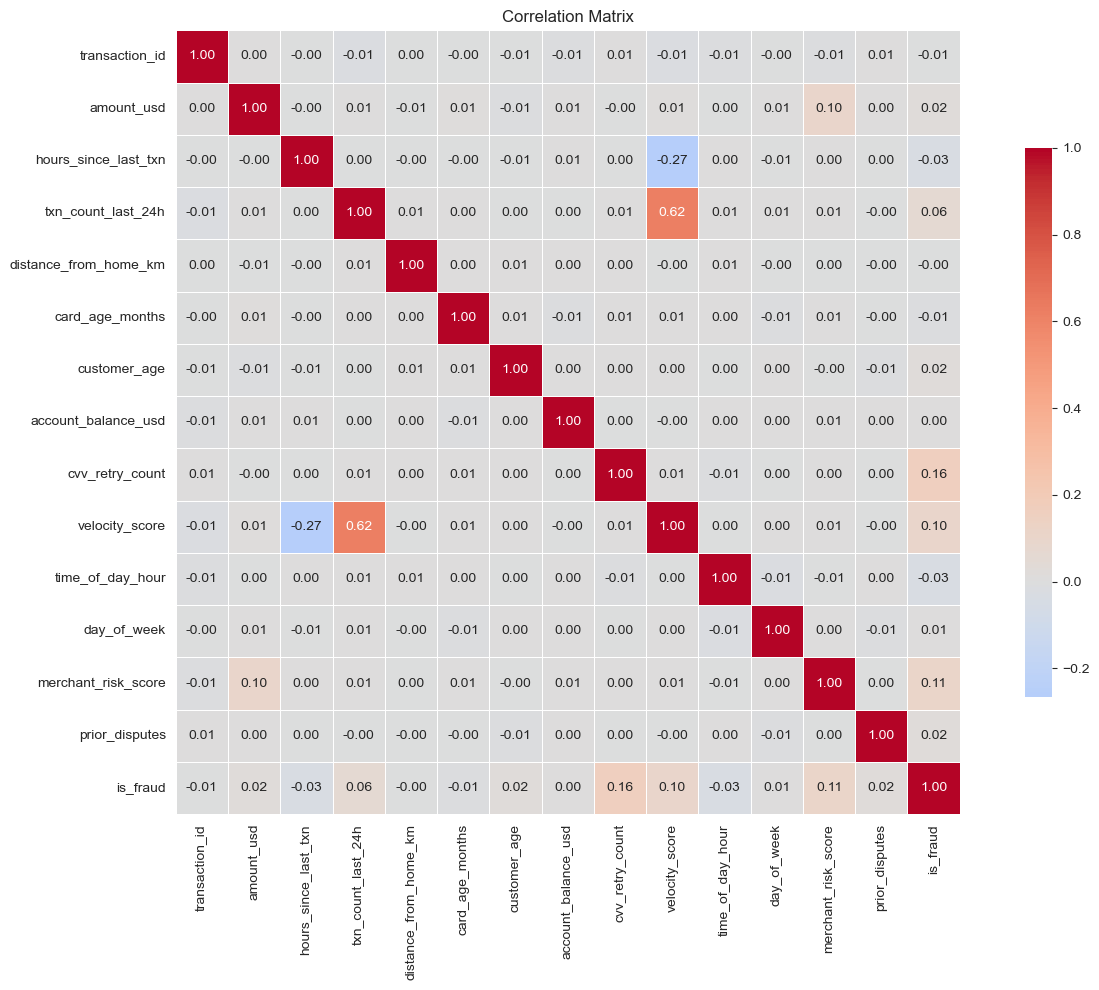

In [11]:
plt.figure(figsize=(14, 10))
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7})
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

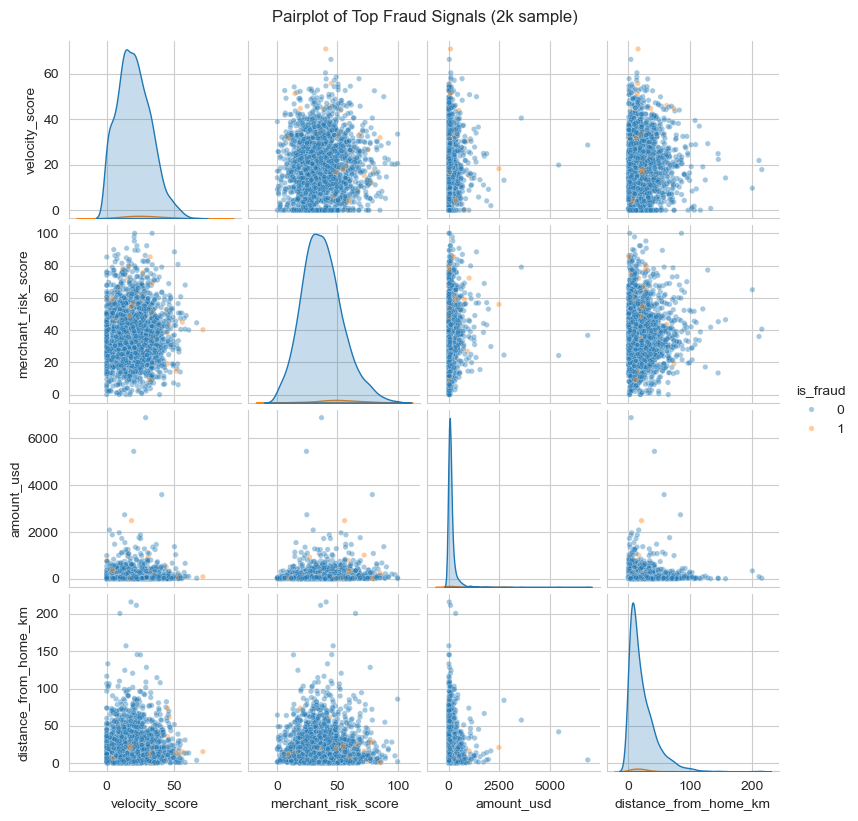

In [12]:
top_features = ['velocity_score', 'merchant_risk_score', 'amount_usd', 'distance_from_home_km', 'is_fraud']

sns.pairplot(
    df[top_features].sample(2000, random_state=42),
    hue='is_fraud',
    plot_kws={'alpha': 0.4, 's': 15},
    diag_kind='kde',
    height=2
)
plt.suptitle('Pairplot of Top Fraud Signals (2k sample)', y=1.02)
plt.show()

# Day 5 — Business Insights

## Top fraud signals
1. **used_vpn** — TBD% fraud rate when 1 vs 1.69% baseline
2. **ip_country_mismatch** — TBD% when 1
3. **merchant_risk_score** — TBD× higher mean in fraud rows

## Time patterns
- Peak hour: TBD (from chart)
- Decision: [engineer / skip] `is_night` feature

## Multicollinearity
- TBD from heatmap: any pair > 0.85?

## Features to deprioritize
- TBD — anything flat across all charts

## Actions for Day 6
- Ratio: amount_usd / account_balance_usd
- Flag combo: used_vpn × ip_country_mismatch
- Time: is_night (if hour chart shows a spike)
- TBD drop: [redundant column from correlation matrix]